In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm

import time
from datetime import date

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

# provides interactive "R studio-like" view of dataframes
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

# ensures function files are visible: can use 'src.loading' for example
sys.path.append(os.path.abspath(".."))

In [7]:
from src.loading import load_data


#df = load_data("../data/spatial_generalization/spatial_generalization_3m.parquet", keep_col='training_status')
# # drop every row from participant p007
#df = df[df['ppid'] != 'p007'].copy()

# ------------------- Spatial Generalization 2.0 m/s
df = load_data("../data/target_trial_spatial_generalization.parquet", keep_col='training_status')



In [9]:
np.unique(df['water_speed_m_s'])

array([-2.,  0.])

In [11]:
# make function to loop through ppid label, attatch a '_{water_speed} based on npunique(water_speed[1])
from src.label_water_speed_ppid import label_water_condtion_ppid


In [13]:
df_labeled = label_water_condtion_ppid(df, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-2.0,0.0]) #-3.0
df_labeled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7327 entries, 0 to 7328
Data columns (total 59 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   experiment                 7327 non-null   object  
 1   ppid                       7327 non-null   object  
 2   session_num                7327 non-null   int32   
 3   trial_num                  7327 non-null   int32   
 4   block_num                  7327 non-null   int32   
 5   trial_num_in_block         7327 non-null   int32   
 6   start_time                 7327 non-null   float64 
 7   end_time                   7327 non-null   float64 
 8   hand                       7327 non-null   object  
 9   target_hit                 7327 non-null   object  
 10  final_ball_state           7327 non-null   object  
 11  type                       7327 non-null   object  
 12  target_position_x          7327 non-null   float64 
 13  target_position_y          7327 non-nu

In [15]:
df_labeled['water_speed_binary2'] = (df_labeled['water_speed_m_s'] != 0.0).astype(int)
df_labeled['water_speed_binary'] = df_labeled['water_speed_binary2']

# drops old col
df_labeled.drop(columns=['water_speed_binary2'], inplace=True)

In [17]:
np.unique(df_labeled['water_speed_binary'])

array([0, 1])

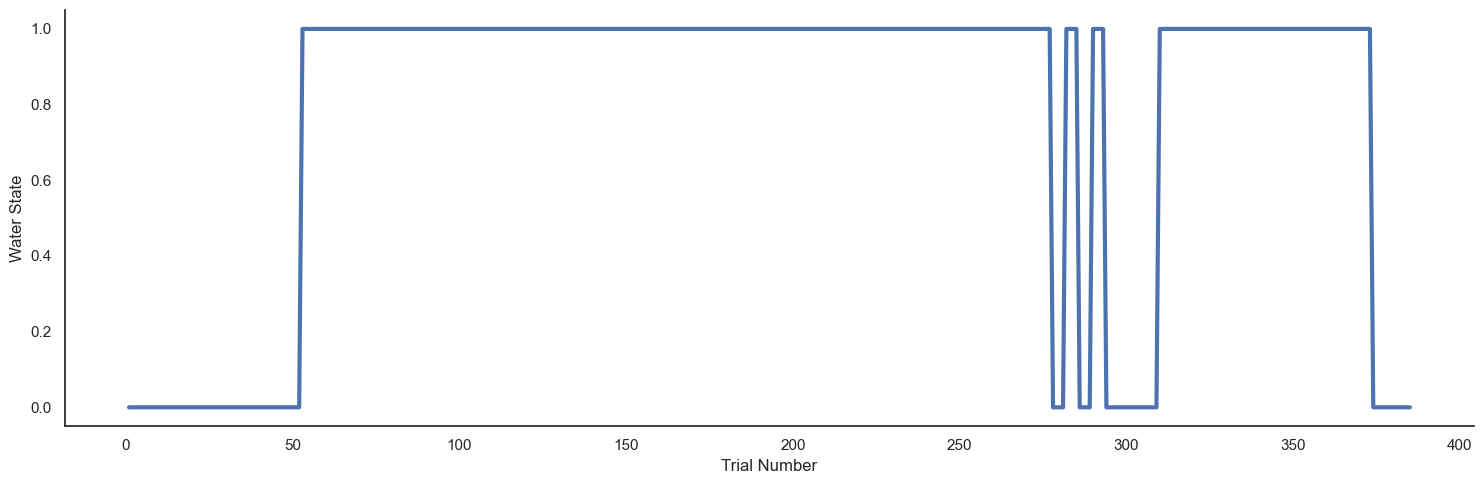

In [19]:
from src.plotting import plot_trial_schedule
g = plot_trial_schedule(df_labeled, y_col='water_speed_binary', context='poster', font_scale=3)

In [21]:
df_labeled['min_x_delta'] = (df_labeled['min_pos_from_target_x'] - df_labeled['target_position_x']) * 100 # convert to cm
df_labeled['min_z_delta'] = (df_labeled['min_pos_from_target_z'] - df_labeled['target_position_z']) * 100


In [23]:
# order targets

from src.features import order_targets

df_labeled['target_x_label'] = order_targets(df_labeled.copy())

0         p0.3
1       neg0.3
2         p0.6
3       neg0.6
4       neg0.3
         ...  
7324      p0.3
7325      p0.3
7326    neg0.6
7327      p0.6
7328    neg0.3
Name: target_x_label, Length: 7327, dtype: category
Categories (4, object): ['neg0.6' < 'neg0.3' < 'p0.3' < 'p0.6']


In [ ]:
### SPEED 3 Trial Schedule

In [15]:
from src.add_phases import label_phases, df_add_phases

phases_sg_3 = label_phases(n_phases=7,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_ST',
                                   'washout_ST',
                                   'washout_1_AT',
                                   'transfer_ST',
                                   'washout_2_AT'])

df_labeled = df_add_phases(df_labeled, 
                           phase_array=phases_sg_3,
                          trial_lo = np.array([1,21,53,278,294,310,374]),
                        trial_hi = np.array([20,52,277,293,309,373,389])
)


df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')]
df_nf

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [ ]:
### SPEED 2 Trial Schedule

In [27]:
from src.add_phases import label_phases, df_add_phases

phases_sg_2 = label_phases(n_phases=10,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_ST',
                                   'washout_ST_1',
                                   'retention_ST_1',
                                    'washout_ST_2',
                                     'retention_ST_2',
                                   'washout_AT_1',
                                   'training_AT',
                                    'washout_AT_2'])

df_labeled = df_add_phases(df_labeled, 
                           phase_array=phases_sg_2,
                          trial_lo = np.array([1,21,53,278,282,286,290,294,310,374]),
                        trial_hi = np.array([20,52,277,281,285,289,293,309,373,385])
)


df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')]
df_nf

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [29]:
np.unique(df_nf['phase'])

array(['baseline', 'retention_ST_1', 'retention_ST_2', 'training_AT',
       'training_ST', 'washout_AT_1', 'washout_AT_2', 'washout_ST_1',
       'washout_ST_2'], dtype=object)

In [31]:
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70),
        axis=1
)
# check
print(df_nf['crossed_threshold'].value_counts())

crossed_threshold
True     6897
False      38
Name: count, dtype: int64


C:\Users\jacob\AppData\Local\Temp\ipykernel_3112\3599073393.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nf['crossed_threshold'] = df_nf.apply(


In [33]:
df_filt = df_nf[df_nf['crossed_threshold']] # retains rows where crossed_threshold == True

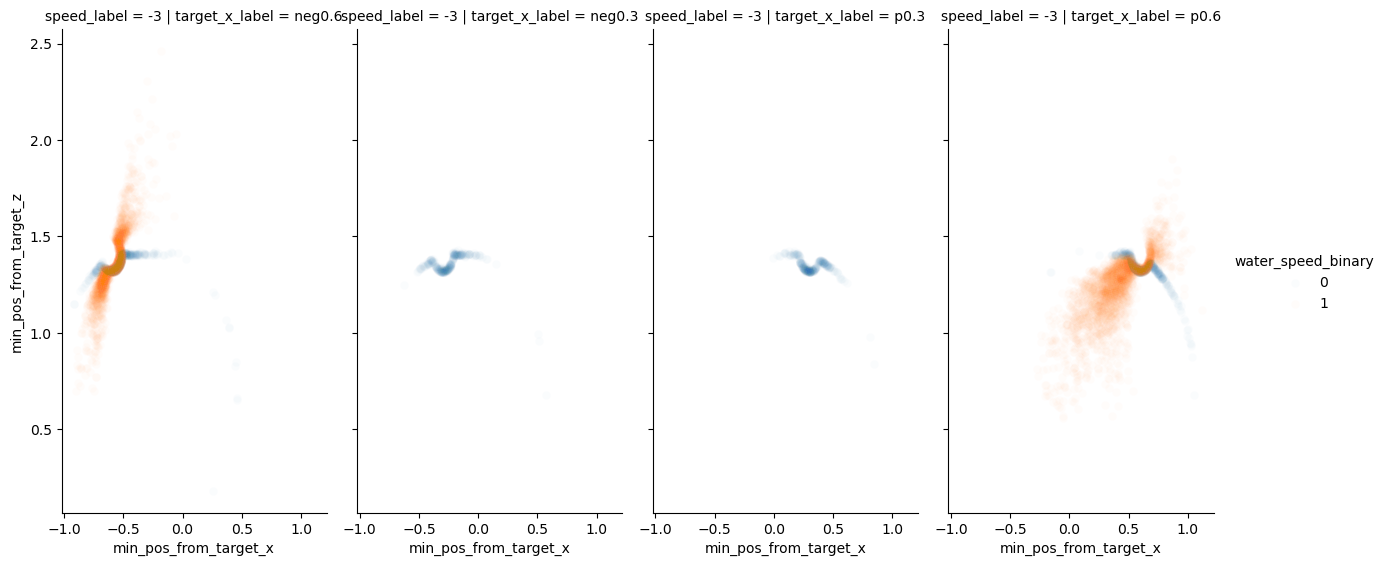

In [21]:
from src.plotting import plot_min_x_z

plot_min_x_z(df_filt,
             c_col='target_x_label',
             r_col='speed_label',
             hue_col = 'water_speed_binary'
            )

In [35]:
from src.cleaning import extract_key_columns

df_small = extract_key_columns(df_nf)
df_small_filt = extract_key_columns(df_filt)

In [37]:
from src.features import point_of_crossing_x

df_small['error_x_plane'] = df_small.apply(point_of_crossing_x, axis=1)
df_small_filt['error_x_plane'] = df_small.apply(point_of_crossing_x, axis=1)

#df_small_filt.to_csv(r"..\data\R_LMM.csv", index=False)

# calculate min point once, save data in function

In [39]:
df_small_filt.to_csv(r"..\data\df_all_phases.csv", index=False)

In [51]:
np.unique(df_small_filt['phase'])

array([-2.,  0.])

In [49]:
df_baseline_washout = df_small_filt[df_small_filt['water_speed_binary'] == 0]
df_baseline_washout

# BASELINE-WASHOUT
df_baseline_washout['phase'].unique()
df_baseline_washout.to_csv(r"..\data\df_baseline_washout.csv", index=False)

In [ ]:
BASELINE

In [53]:
df_baseline = df_small_filt[df_small_filt['phase'].str.startswith('b')]
df_baseline

df_baseline.to_csv(r"..\data\df_baseline.csv", index=False)

In [55]:
from src.features import summarize_phase
baseline = summarize_phase(df_small, phase='baseline', y_col='error_x_plane',  ppid_col='ppid_full', lat_error_col='min_x_delta')

baseline_filt = summarize_phase(df_small_filt, phase='baseline',  y_col='error_x_plane', ppid_col='ppid_full', lat_error_col = 'min_x_delta')

baseline_filt

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [31]:
df_baseline_washout['phase'].unique()

['baseline', 'washout_ST', 'washout_1_AT', 'washout_2_AT']
Categories (6, object): ['baseline', 'training_ST', 'transfer_ST', 'washout_1_AT', 'washout_2_AT', 'washout_ST']

In [57]:
# combine baseline error back to main df
df_BC = df_small.merge(baseline, on=['ppid_full', 'target_x_label'], how='left')

df_filt_BC = df_small_filt.merge(baseline_filt, on=['ppid_full', 'target_x_label'], how='left')


# baseline correct min distance 
df_BC['baseline_corrected_dist'] = df_BC['ball_dist_to_center_cm'] - df_BC['mean_ball_dist_cm']
# baseline corrected error x plane
df_BC['min_x_delta_BC'] = df_BC['min_x_delta'] - df_BC['mean_ball_dist_x_cm']
# baseline corrected launch dev
df_BC['baseline_corrected_dev'] = df_BC['launch_deviation'] - df_BC['mean_ball_launch_dev']
# baseline corrected launch speed
df_BC['baseline_corrected_speed'] = df_BC['launch_Speed'] - df_BC['mean_ball_launch_speed']


# filtered data baseline correct
df_filt_BC['baseline_corrected_dist'] = df_filt_BC['ball_dist_to_center_cm'] - df_filt_BC['mean_ball_dist_cm']
# baseline corrected error x plane
df_filt_BC['min_x_delta_BC'] = df_filt_BC['min_x_delta'] - df_filt_BC['mean_ball_dist_x_cm']
# baseline corrected launch dev
df_filt_BC['baseline_corrected_dev'] = df_filt_BC['launch_deviation'] - df_filt_BC['mean_ball_launch_dev']
# baseline corrected launch speed
df_filt_BC['baseline_corrected_speed'] = df_filt_BC['launch_Speed'] - df_filt_BC['mean_ball_launch_speed']

In [29]:
df_filt_BC

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

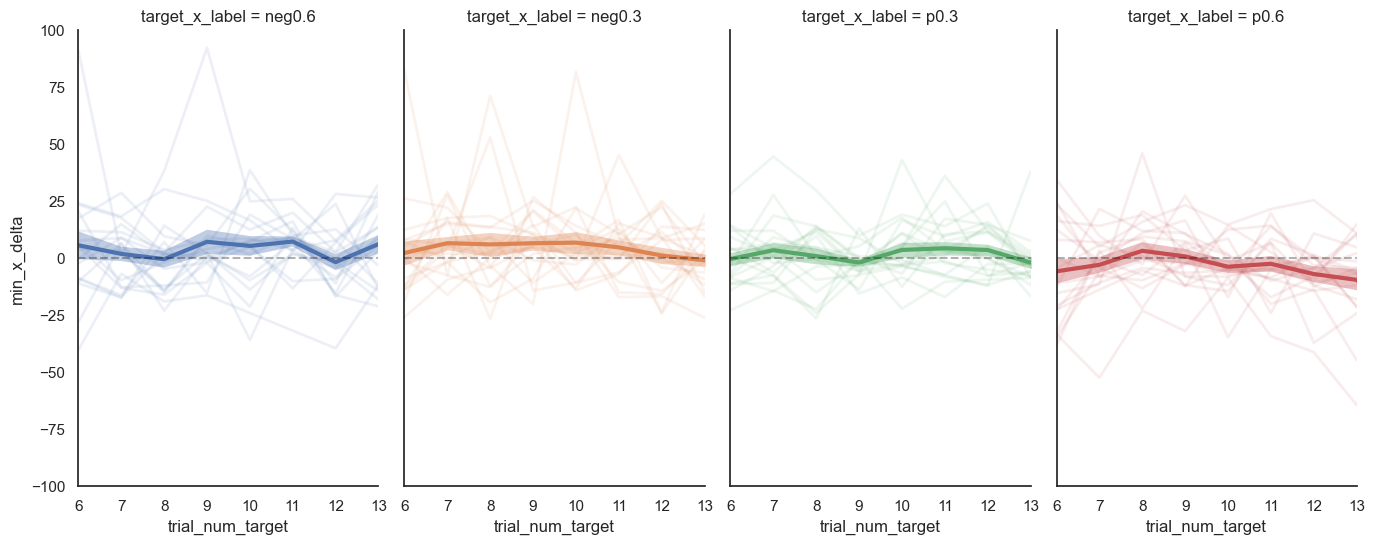

In [61]:
from src.plotting import plot_baseline

# baseline only:

plot_baseline(df_filt_BC, 
              context='notebook', 
              font_scale=3, 
              x_col='trial_num_target',
              y_col='min_x_delta', 
              ppid_col='ppid_full', 
              cond_col='speed_label', 
              y_lim=(-100,100)
              )
#plot_baseline(df_small, y_col='launch_deviation', y_lim=(-30,30))

#plot_baseline(df_small, y_col='launch_Speed', y_lim=(0.0,4.0))

In [31]:
df_filt_BC.columns

Index(['experiment', 'ppid_full', 'speed_label', 'trial_num', 'phase',
       'trial_num_target', 'launch_deviation', 'launch_dev_z', 'launch_Speed',
       'launch_Speed_z', 'ball_dist_to_center_cm', 'min_x_delta',
       'min_z_delta', 'target_hit', 'water_speed_binary', 'water_speed_m_s',
       'target_x_label', 'sign_label', 'set_order', 'ball_pos_x', 'ball_pos_z',
       'min_pos_from_target_x', 'min_pos_from_target_z', 'target_position_x',
       'target_position_z', 'target_angle_90', 'error_x_plane',
       'mean_ball_dist_cm', 'min_ball_dist_cm', 'mean_ball_dist_x_cm',
       'mean_ball_launch_dev', 'mean_ball_launch_speed',
       'baseline_corrected_dist', 'min_x_delta_BC', 'baseline_corrected_dev',
       'baseline_corrected_speed'],
      dtype='object')

In [29]:
from src.early_late_exposure import early_late_means

early_late_4_means = early_late_means(
                                            df_filt_BC,
                                            error_col='min_x_delta_BC', #baseline_corrected_dist
                                            window_size=4,
                                            ppid='ppid_full',
                                            phases = ['ST_training']
                                            )
early_late_4_means

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ppid,'phase','speed_label','target_x_label'])
C:\Users\jacob\water_current_MA\src\early_late_exposure.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ordered = (df_phase
C:\Users\jacob\water_current_MA\src\early_late_exposure.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  early_to_late.groupby

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)


ValueError: Could not interpret value `section` for `x`. An entry with this name does not appear in `data`.

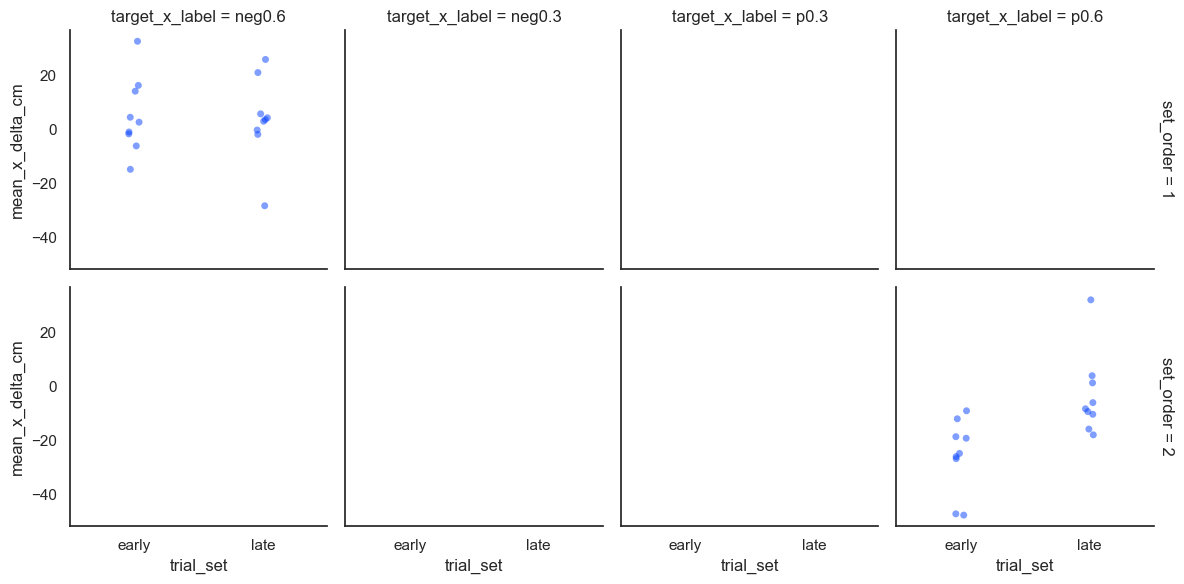

In [89]:
from src.plotting import plot_early_late_exposure

#early_late_4_means['training_status'].unique()

# if target doesnrt exist dont make facet...


plot_early_late_exposure(early_late_4_means,
                         y_col='mean_x_delta_cm',
                         cond_col='speed_label', 
                         ppid_col='ppid_full',
                         show_zero_line=True)

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

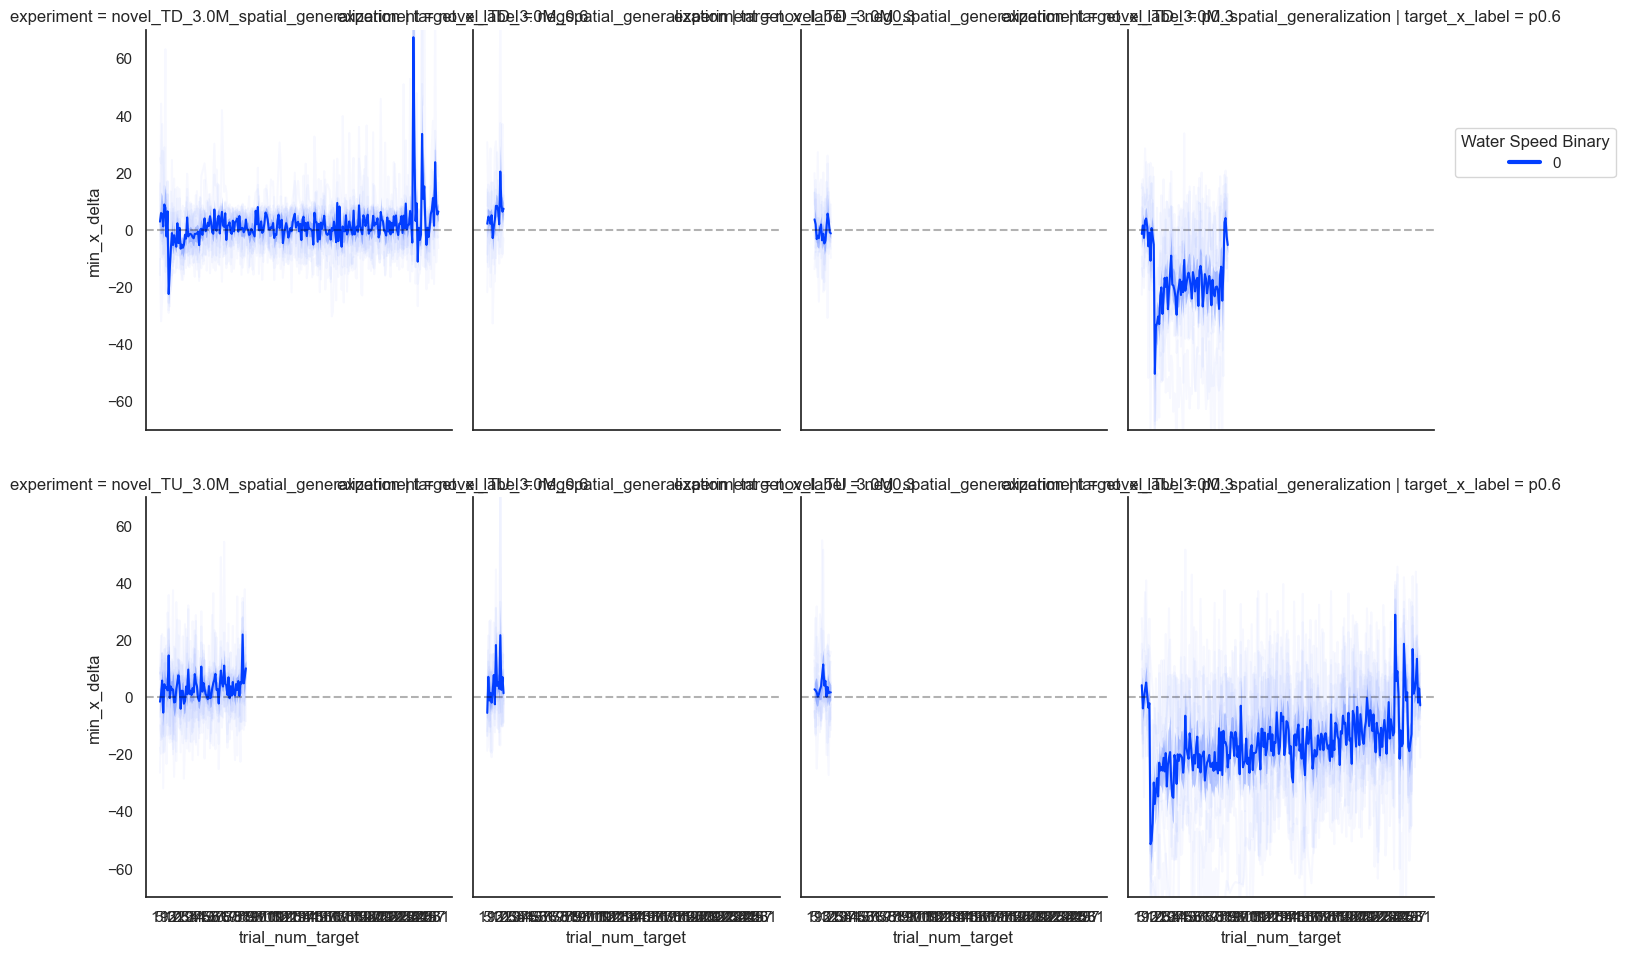

In [37]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(df_filt_BC, 
                     cond_col='water_speed_binary',
                     ppid_col='ppid_full',
                     row_col='experiment',
                     y_col = 'min_x_delta', 
                     x_col='trial_num_target',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-70,70),
                     show_zero_line=True
                    )

In [ ]:
SINGLE-TARGET TRANSFER

In [82]:
df_filt_BC['phase'].unique

<bound method Series.unique of 0           baseline
1           baseline
2           baseline
3           baseline
4           baseline
            ...     
6810    washout_2_AT
6811    washout_2_AT
6812    washout_2_AT
6813    washout_2_AT
6814    washout_2_AT
Name: phase, Length: 6815, dtype: category
Categories (6, object): ['baseline', 'training_ST', 'transfer_ST', 'washout_1_AT', 'washout_2_AT', 'washout_ST']>

In [75]:
from src.filter_phase import filter_for_phase
df_current = filter_for_phase(df_filt_BC, phase_key='tr', inc_phase=True, ppid_col='ppid_full') 

C:\Users\jacob\water_current_MA\src\filter_phase.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  selected_phase['phase_trial_target'] = selected_phase.groupby([ppid_col, 'phase','target_x_label']).cumcount() + 1
C:\Users\jacob\water_current_MA\src\filter_phase.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_check = selected_phase.groupby([ppid_col,'target_x_label'])['phase_trial_target'].max()


In [77]:
df_training_retention = df_current[0].copy()

df_training_retention['phase'].unique()

['retention_ST_1', 'retention_ST_2', 'training_AT', 'training_ST']
Categories (9, object): ['baseline', 'retention_ST_1', 'retention_ST_2', 'training_AT', ..., 'washout_AT_1', 'washout_AT_2', 'washout_ST_1', 'washout_ST_2']

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

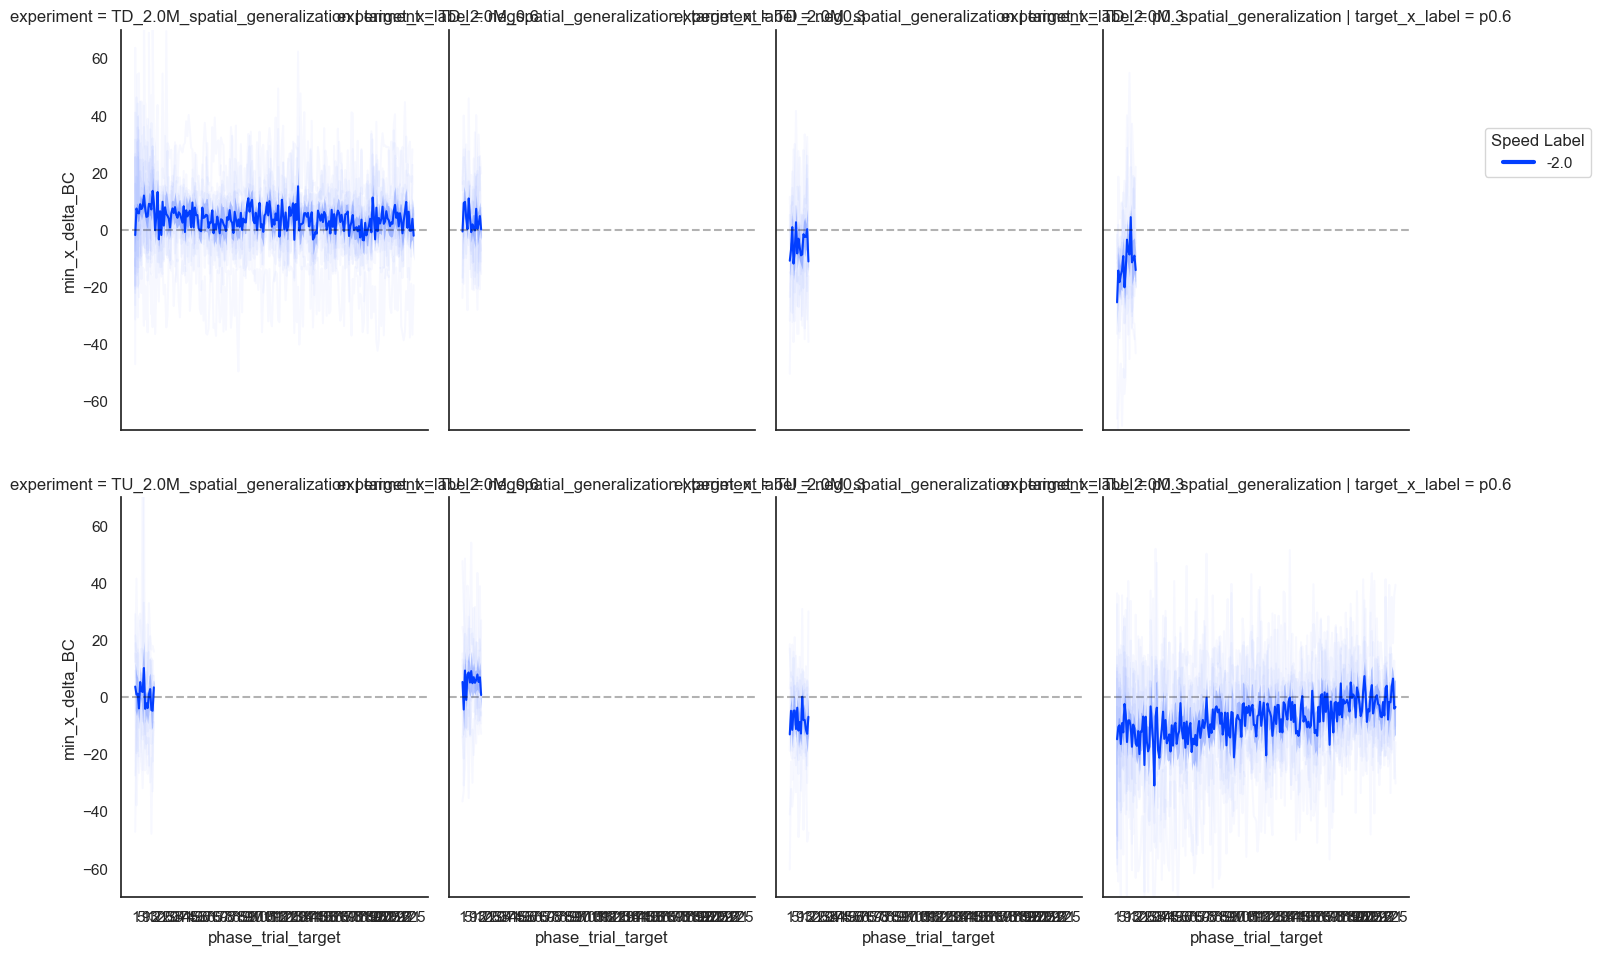

In [79]:
from src.plotting import plot_exposure_trials

plot_exposure_trials(df_training_retention, 
                     cond_col='speed_label',
                     ppid_col='ppid_full',
                     row_col='experiment',
                     y_col = 'min_x_delta_BC', 
                     x_col='phase_trial_target',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-70,70),
                     show_zero_line=True
                    )

In [117]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_training_retention,
            features = ['min_pos_from_target_x','min_pos_from_target_z'],
            group_cols = ['experiment','water_speed_m_s','target_x_label'], # set_order
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table

C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data_current.groupby(group_cols)


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [119]:
df_angles = df_training_retention.copy()

group_cols = ['water_speed_m_s','target_x_label'] # set_order

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table[group_cols + new_cols], how="left", on=group_cols)
# should be true
#len(df_angles_v['pc_vector_1_angle'].unique()) == 16

In [121]:
df_angles_v['pc_vector_1_angle'].unique()
df_angles_v[['experiment', 'target_x_label', 'pc_vector_1_angle']].drop_duplicates()

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


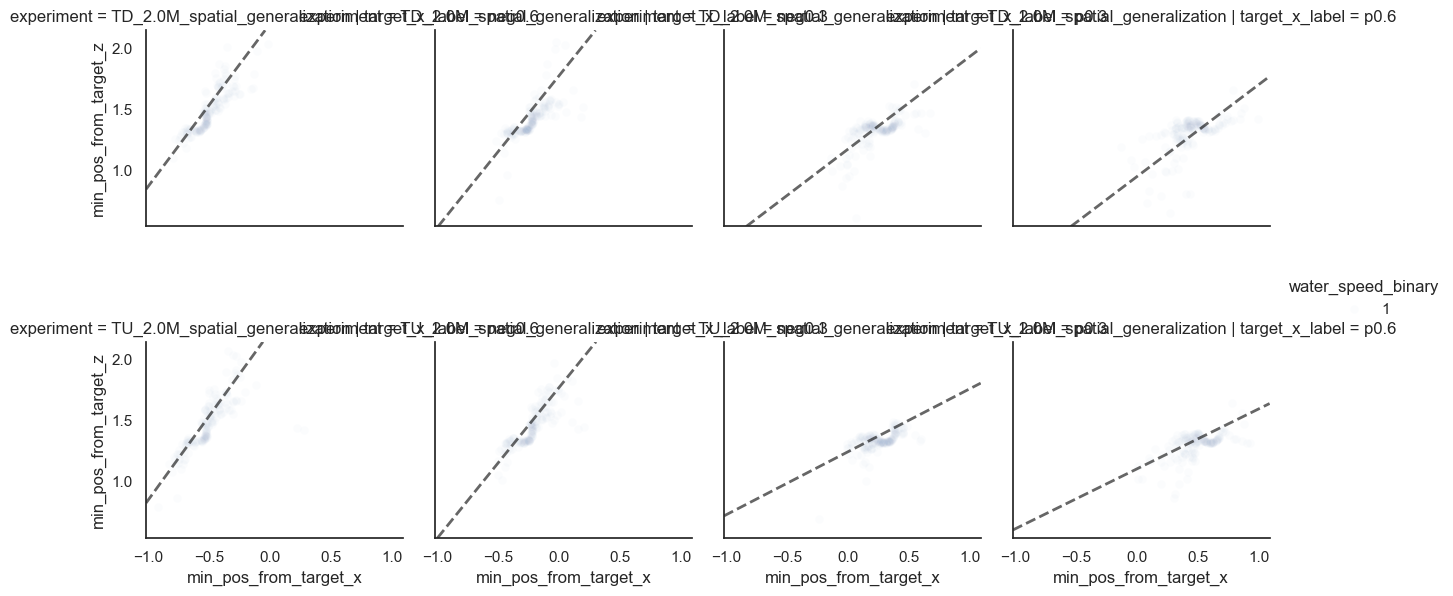

In [43]:
# -2.0 M/S

from src.plotting import plot_min_x_z

df_n2 = df_training_retention[df_training_retention['water_speed_m_s'] == -2.0].copy()

# slopes for n3 data
slope_key_n2 = np.array([[53.167841, 51.254056, 37.247702, 37.065538],
             [54.059303, 51.059116, 27.345653, 26.224002]])

plot_min_x_z(df_n2,
             show_slopes = True,
             slope_array = slope_key_n2,
             target_x_array = [-0.6, -0.3, 0.3, 0.6],
             c_col='target_x_label',
             r_col='experiment',
             hue_col = 'water_speed_binary'
            )

In [123]:
from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x',
                  target_z_col='target_position_z',
                  features = ['min_pos_from_target_x','min_pos_from_target_z'],
                  water_col = 'water_speed_m_s'
                 )

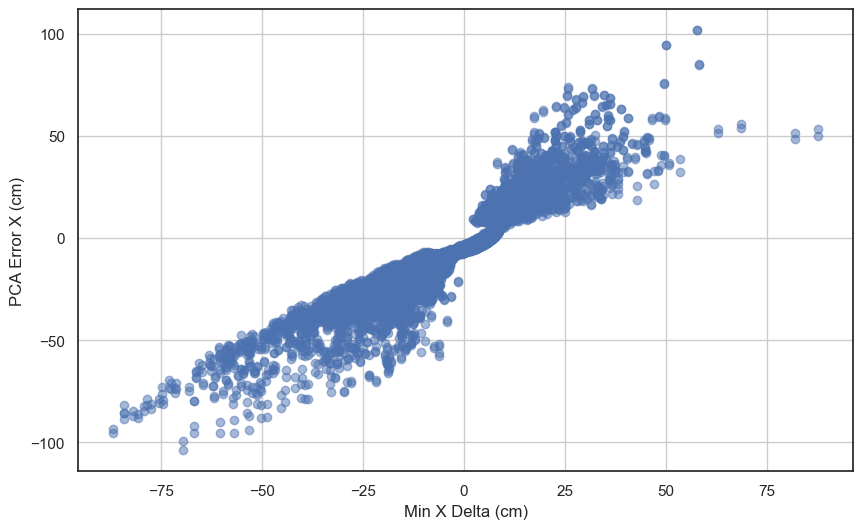

In [125]:
plt.figure(figsize=(10,6))
plt.scatter(PCA_error_df['min_x_delta'], PCA_error_df['PCA_error_X_cm'], alpha=0.5)

plt.xlabel('Min X Delta (cm)')
plt.ylabel('PCA Error X (cm)')
plt.grid(True)
plt.show() 

In [127]:
# using geometric error (min_x_delta) we will baseline correct the PCA derived measure
baseline_lookup = baseline_filt.groupby(['ppid_full', 'target_x_label'])['mean_ball_dist_x_cm'].mean().reset_index()
# combine baseline error back to main df
PCA_error_df_bt = PCA_error_df.merge(baseline_lookup, on=['ppid_full', 'target_x_label'], how='left').copy()

PCA_error_df_bt['PCA_error_X_cm_BC'] = PCA_error_df_bt['PCA_error_X_cm'] - PCA_error_df_bt['mean_ball_dist_x_cm_y']

C:\Users\jacob\AppData\Local\Temp\ipykernel_3112\2186487001.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baseline_lookup = baseline_filt.groupby(['ppid_full', 'target_x_label'])['mean_ball_dist_x_cm'].mean().reset_index()


In [133]:
PCA_error_df_bt['water_speed_m_s'].unique()

array([-2.])

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

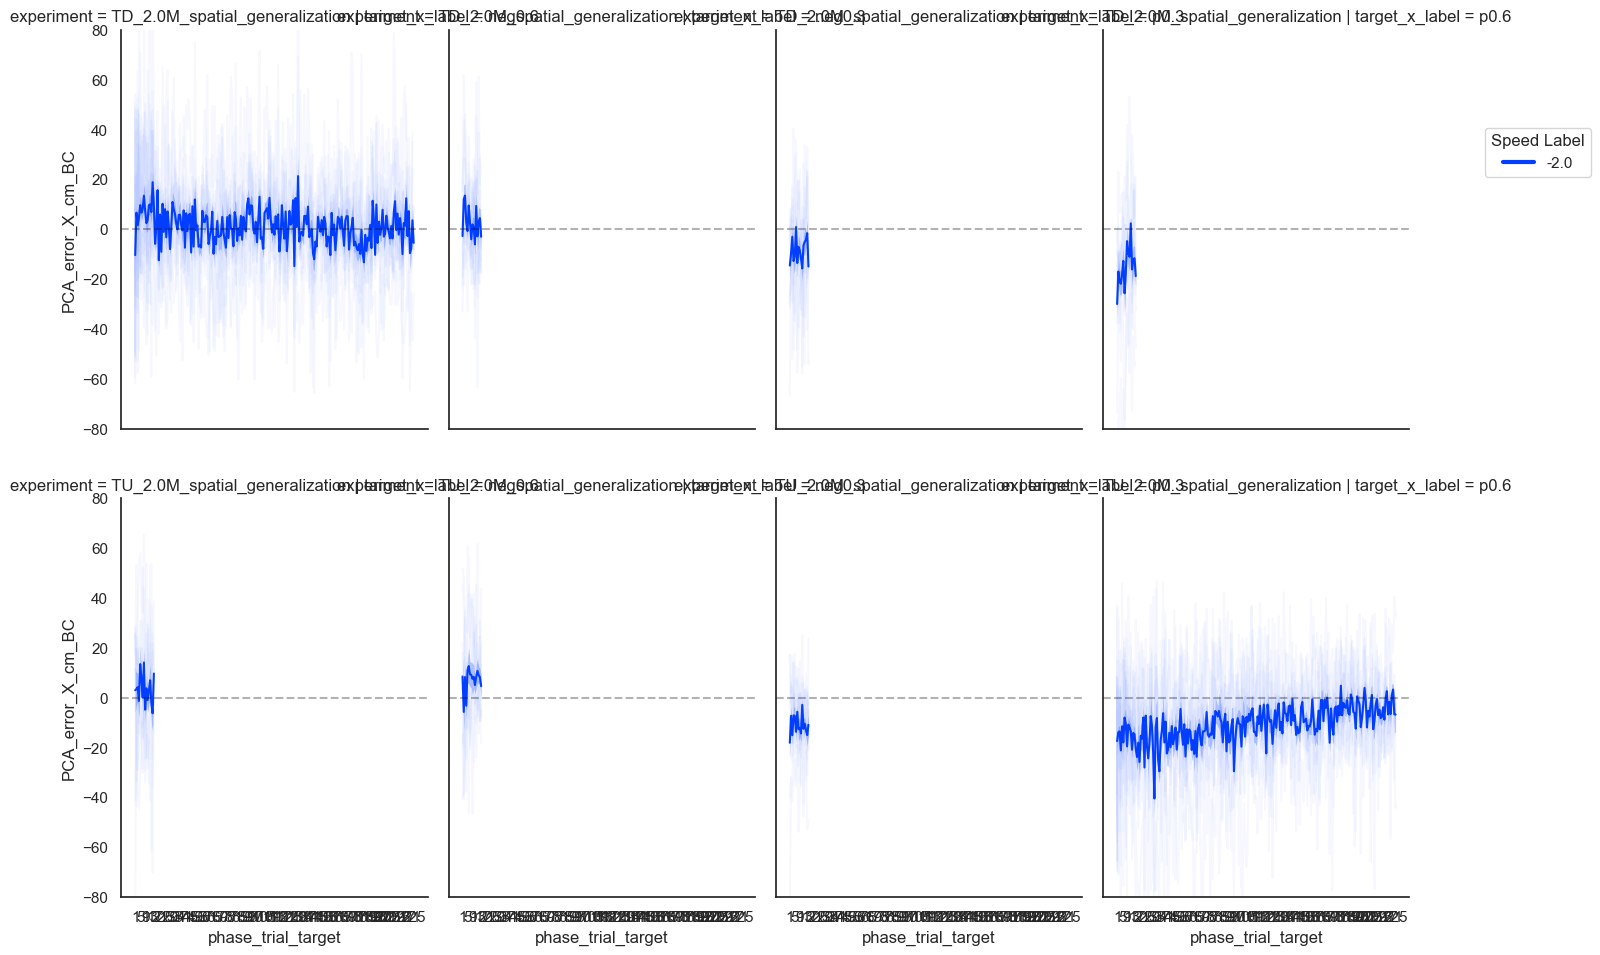

In [131]:
from src.plotting import plot_exposure_trials

# baseline corrected
plot_exposure_trials(PCA_error_df_bt, 
                     row_col='experiment',
                     cond_col='speed_label',
                     ppid_col='ppid_full',
                     y_col = 'PCA_error_X_cm_BC', 
                     x_col='phase_trial_target',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-80,80),
                     show_zero_line=True
                    )

In [137]:
PCA_error_df_bt.to_csv(r"..\data\df_PCA_current.csv", index=False)

In [ ]:
# ALL MOVING-WATER

In [103]:
# ALL MOVING-WATER
df_water_current = df_filt_BC[df_filt_BC['water_speed_binary'] != 0.0]

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


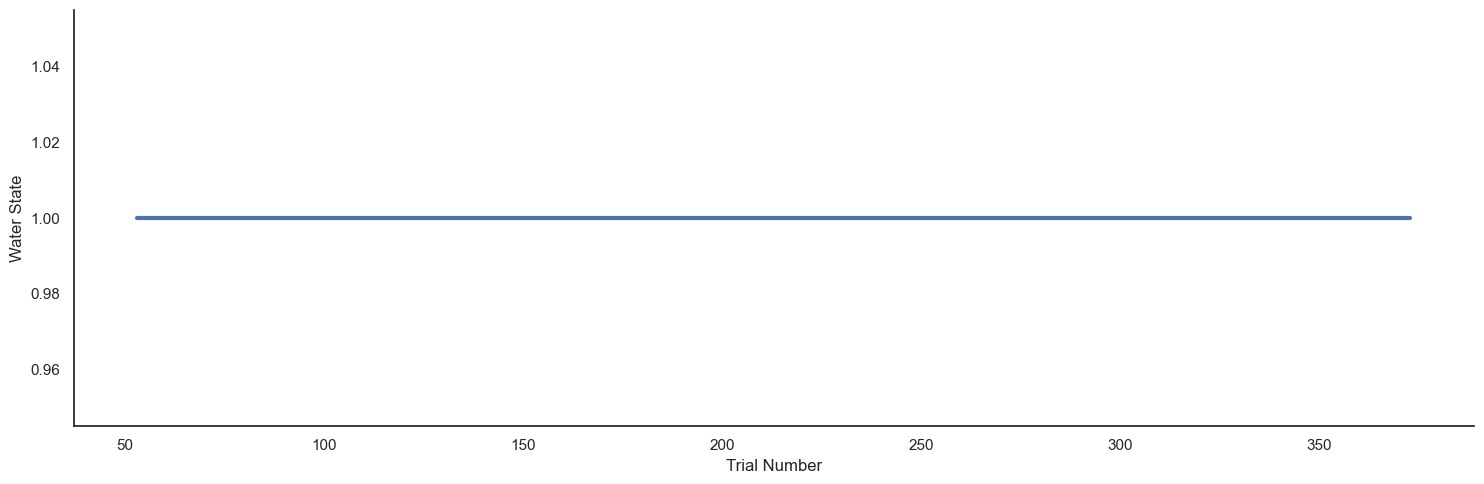

In [105]:
from src.plotting import plot_trial_schedule
g = plot_trial_schedule(df_water_current, y_col='water_speed_binary', context='poster', font_scale=3)

In [109]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_water_current,
            features = ['min_pos_from_target_x','min_pos_from_target_z'],
            group_cols = ['experiment','water_speed_m_s','target_x_label'], # set_order
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table

C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data_current.groupby(group_cols)


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


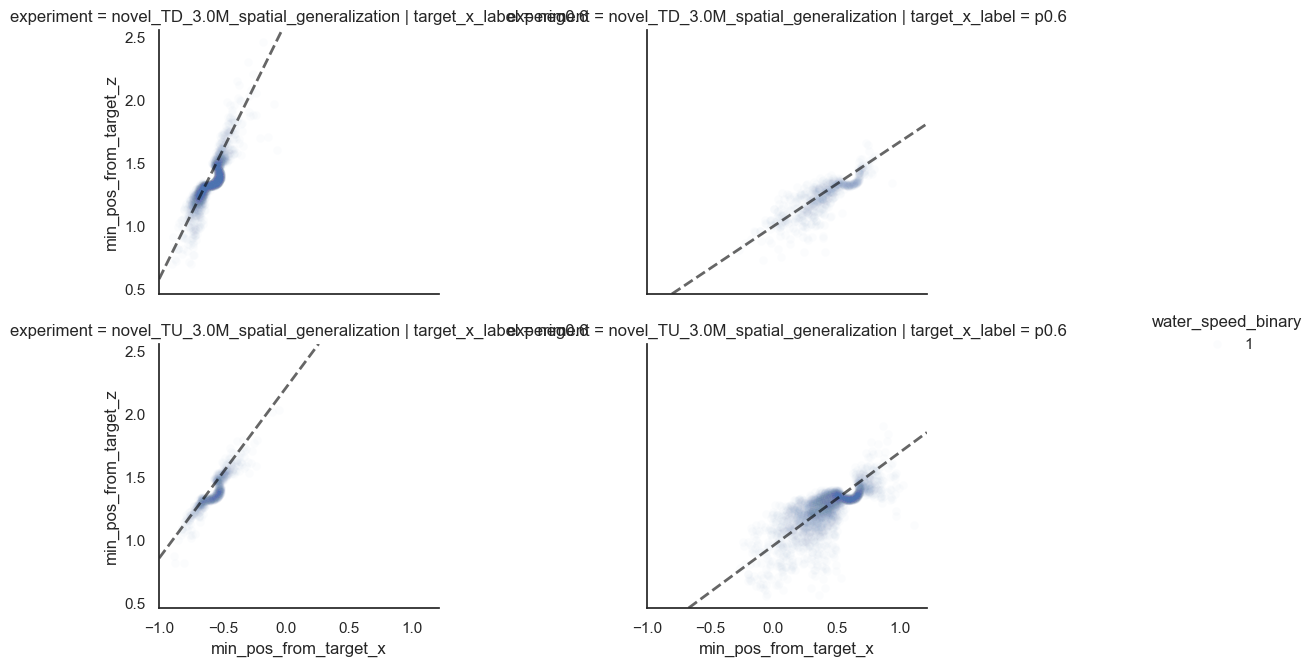

In [115]:
# -3.0 M/S

from src.plotting import plot_min_x_z

df_n3 = df_water_current[df_water_current['water_speed_m_s'] == -3.0].copy()

# slopes for n3 data
slope_key_n3 = np.array([[63.733853, 33.710848],
             [53.336088, 36.385904]])

plot_min_x_z(df_n3,
             show_slopes = True,
             slope_array = slope_key_n3,
             target_x_array = [-0.6, 0.6],
             c_col='target_x_label',
             r_col='experiment',
             hue_col = 'water_speed_binary'
            )

In [117]:
df_angles = df_post_baseline.copy()

group_cols = ['experiment', 'water_speed_m_s','target_x_label'] # set_order

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table[group_cols + new_cols], how="left", on=group_cols)
# should be true
#len(df_angles_v['pc_vector_1_angle'].unique()) == 16

In [121]:
from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x',
                  target_z_col='target_position_z',
                  features = ['min_pos_from_target_x','min_pos_from_target_z'],
                  water_col = 'water_speed_m_s'
                 )

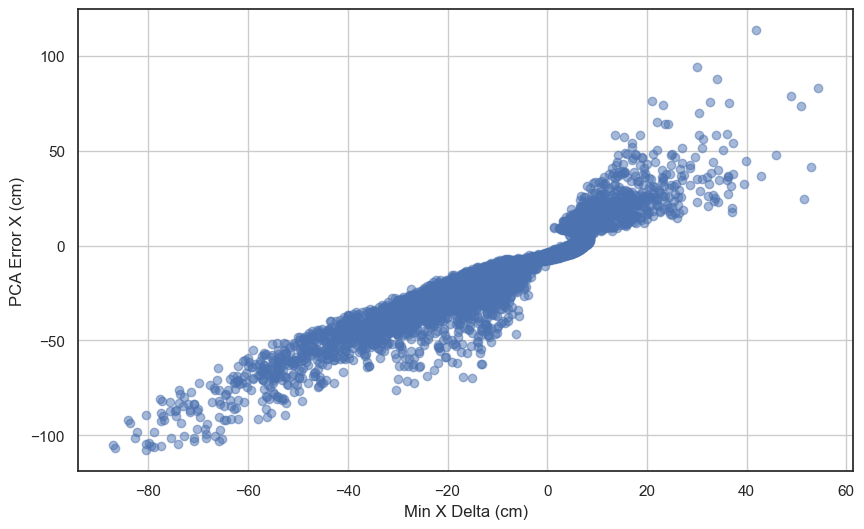

In [123]:

plt.figure(figsize=(10,6))
plt.scatter(PCA_error_df['min_x_delta'], PCA_error_df['PCA_error_X_cm'], alpha=0.5)

plt.xlabel('Min X Delta (cm)')
plt.ylabel('PCA Error X (cm)')
plt.grid(True)
plt.show() 

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

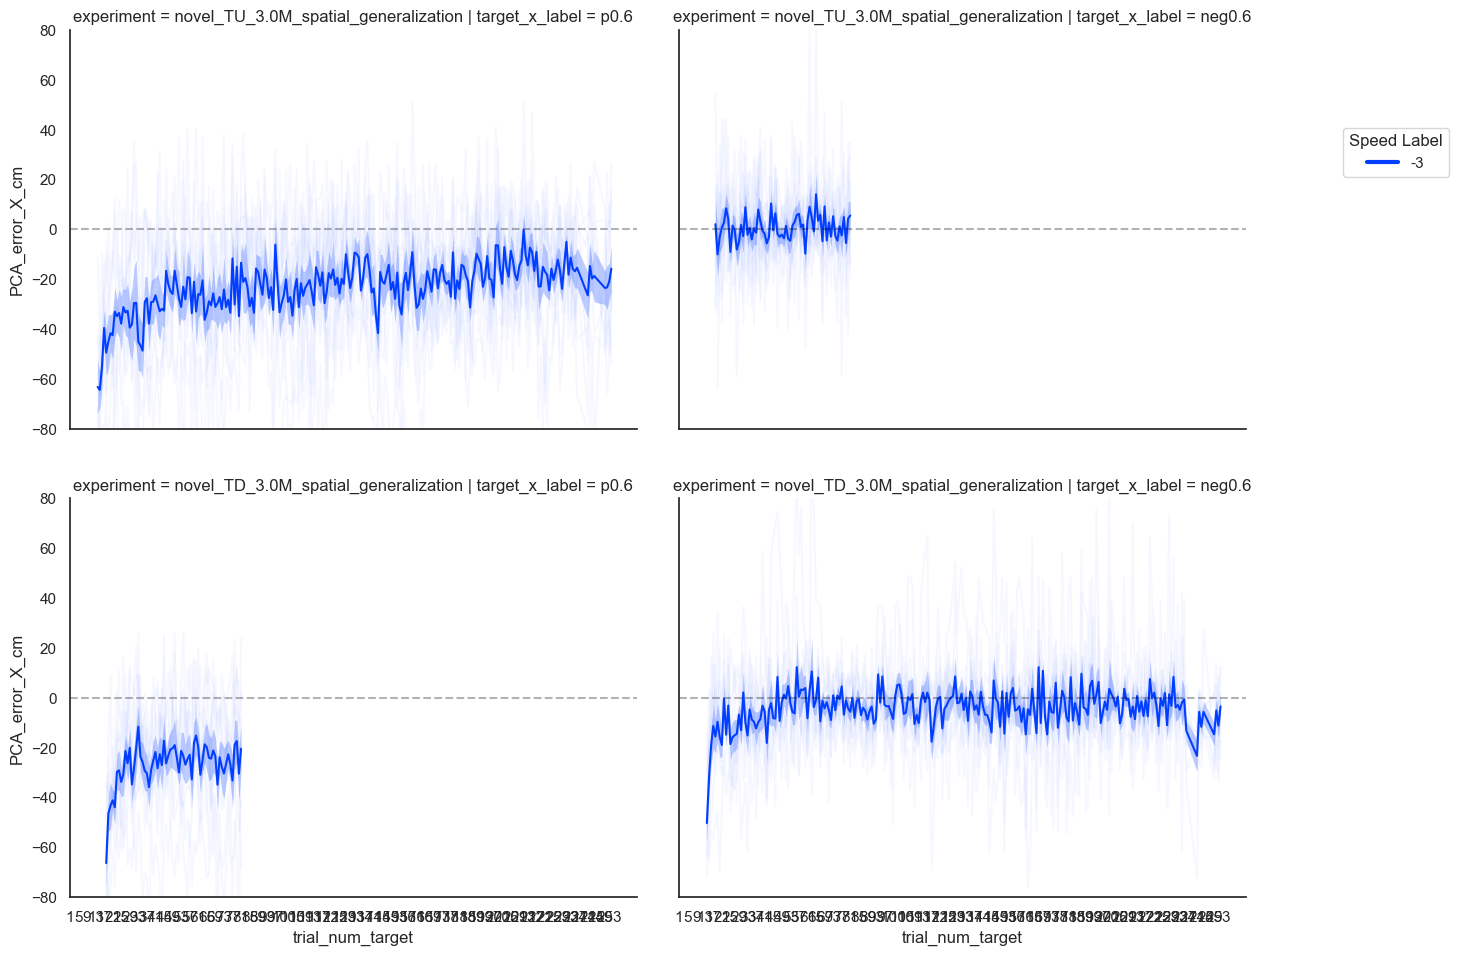

In [127]:
from src.plotting import plot_exposure_trials

# raw data
plot_exposure_trials(PCA_error_df, 
                     row_col='experiment',
                     cond_col='speed_label',
                     ppid_col='ppid_full',
                     y_col = 'PCA_error_X_cm', 
                     x_col='trial_num_target',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-80,80),
                     show_zero_line=True
                    )

In [131]:
PCA_error_df.to_csv(r"..\data\df_PCA_current.csv", index=False)